# Librerias a usar



In [ ]:
pip install simpy

In [ ]:
import simpy
import random
import math
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importacion de datos de muestra

In [13]:
#Para la importanción se debera colocar el archivo excel de simulacion_cajas en el colab
df_cajas= pd.read_excel('simulacion_cajas.xlsx',skiprows=2)
display(df_cajas)

,Cliente,Hora de llegada (observada),Tiempo entre llegadas (min),Cajero que atendio,Tiempo de espera (min),Tiempo de atencion (min)
0,1,09:00:57,0.95,1,0.00,1.58
1,2,09:02:22,1.42,2,0.00,3.10
2,3,09:04:01,1.65,1,0.00,1.72
3,4,09:11:48,7.79,2,0.00,8.18
4,5,09:16:34,4.76,1,0.00,12.57
...,...,...,...,...,...,...
95,96,13:42:04,3.58,1,0.25,9.82
96,97,13:44:55,2.85,2,5.52,10.70
97,98,13:47:34,2.66,1,4.56,4.19
98,99,13:47:58,0.40,1,8.35,9.52


#  Análisis estadístico de datos

In [17]:
# Hallamos la media
media_tiempo_llegada = df_cajas['Tiempo entre llegadas (min)'].mean()
media_Tiempo_espera = df_cajas['Tiempo de espera (min)'].mean()
media_tiempo_atencion = df_cajas['Tiempo de atencion (min)'].mean()

print(f"Media del tiempo entre llegadas: {media_tiempo_llegada:.2f} minutos")
print(f"Media del tiempo de espera: {media_Tiempo_espera:.2f} minutos")
print(f"Media del tiempo de atención: {media_tiempo_atencion:.2f} minutos")

Media del tiempo entre llegadas: 2.88 minutos
Media del tiempo de espera: 12.84 minutos
Media del tiempo de atención: 5.85 minutos


In [15]:
# Hallamos la mediana
mediana_tiempo_llegada = df_cajas['Tiempo entre llegadas (min)'].median()
mediana_Tiempo_espera = df_cajas['Tiempo de espera (min)'].median()
mediana_tiempo_atencion = df_cajas['Tiempo de atencion (min)'].median()

print(f"Mediana del tiempo entre llegadas: {mediana_tiempo_llegada:.2f} minutos")
print(f"Mediana del tiempo de espera: {mediana_Tiempo_espera:.2f} minutos")
print(f"Mediana del tiempo de atención: {mediana_tiempo_atencion:.2f} minutos")

Mediana del tiempo entre llegadas: 2.49 minutos
Mediana del tiempo de espera: 11.70 minutos
Mediana del tiempo de atención: 5.23 minutos


In [ ]:
# Hallamos el valor mínimo y máximo
min_tiempo_llegada = df_cajas['Tiempo entre llegadas (min)'].min()
min_Tiempo_espera = df_cajas['Tiempo de espera (min)'].min()
min_tiempo_atencion = df_cajas['Tiempo de atencion (min)'].min()

max_tiempo_llegada = df_cajas['Tiempo entre llegadas (min)'].max()
max_Tiempo_espera = df_cajas['Tiempo de espera (min)'].max()
max_tiempo_atencion = df_cajas['Tiempo de atencion (min)'].max()

print(f"Valor mínimo del tiempo entre llegadas: {min_tiempo_llegada:.2f} minutos | Valor máximo: {max_tiempo_llegada:.2f} minutos")
print(f"Valor mínimo del tiempo de espera: {min_Tiempo_espera:.2f} minutos | Valor máximo: {max_Tiempo_espera:.2f} minutos")
print(f"Valor mínimo del tiempo de atención: {min_tiempo_atencion:.2f} minutos | Valor máximo: {max_tiempo_atencion:.2f} minutos")

Valor mínimo del tiempo entre llegadas: 0.05 minutos | Valor máximo: 13.02 minutos
Valor mínimo del tiempo de espera: 0.00 minutos | Valor máximo: 37.91 minutos
Valor mínimo del tiempo de atención: 0.30 minutos | Valor máximo: 20.52 minutos


In [19]:
# Hallamos la desviación estándar
desv_tiempo_llegada = df_cajas['Tiempo entre llegadas (min)'].std()
desv_Tiempo_espera = df_cajas['Tiempo de espera (min)'].std()
desv_tiempo_atencion = df_cajas['Tiempo de atencion (min)'].std()

print(f"Desviación estándar del tiempo entre llegadas: {desv_tiempo_llegada:.2f} minutos")
print(f"Desviación estándar del tiempo de espera: {desv_Tiempo_espera:.2f} minutos")
print(f"Desviación estándar del tiempo de atención: {desv_tiempo_atencion:.2f} minutos")

Desviación estándar del tiempo entre llegadas: 2.67 minutos
Desviación estándar del tiempo de espera: 9.83 minutos
Desviación estándar del tiempo de atención: 4.04 minutos


In [ ]:
# Hallamos percentiles (25%, 50% y 75%) para el tiempo entre llegadas
percentil_25_tiempo_llegada = df_cajas['Tiempo entre llegadas (min)'].quantile(0.25)
percentil_50_tiempo_llegada = df_cajas['Tiempo entre llegadas (min)'].quantile(0.50)
percentil_75_tiempo_llegada = df_cajas['Tiempo entre llegadas (min)'].quantile(0.75)

print(f"Percentil 25 del tiempo entre llegadas: {percentil_25_tiempo_llegada:.2f} minutos")
print(f"Percentil 50 del tiempo entre llegadas: {percentil_50_tiempo_llegada:.2f} minutos")
print(f"Percentil 75 del tiempo entre llegadas: {percentil_75_tiempo_llegada:.2f} minutos")

Percentil 25 del tiempo entre llegadas: 0.86 minutos
Percentil 50 del tiempo entre llegadas: 2.49 minutos
Percentil 75 del tiempo entre llegadas: 3.70 minutos


In [ ]:
# Hallamos percentiles (25%, 50% y 75%) para el tiempo de espera
percentil_25_tiempo_espera = df_cajas['Tiempo de espera (min)'].quantile(0.25)
percentil_50_tiempo_espera = df_cajas['Tiempo de espera (min)'].quantile(0.50)
percentil_75_tiempo_espera = df_cajas['Tiempo de espera (min)'].quantile(0.75)

print(f"Percentil 25 del tiempo de espera: {percentil_25_tiempo_espera:.2f} minutos")
print(f"Percentil 50 del tiempo de espera: {percentil_50_tiempo_espera:.2f} minutos")
print(f"Percentil 75 del tiempo de espera: {percentil_75_tiempo_espera:.2f} minutos")

Percentil 25 del tiempo de espera: 4.94 minutos
Percentil 50 del tiempo de espera: 11.70 minutos
Percentil 75 del tiempo de espera: 19.25 minutos


In [ ]:
# Hallamos percentiles (25%, 50% y 75%) para el tiempo de atención
percentil_25_tiempo_atencion = df_cajas['Tiempo de atencion (min)'].quantile(0.25)
percentil_50_tiempo_atencion = df_cajas['Tiempo de atencion (min)'].quantile(0.50)
percentil_75_tiempo_atencion = df_cajas['Tiempo de atencion (min)'].quantile(0.75)

print(f"Percentil 25 del tiempo de atención: {percentil_25_tiempo_atencion:.2f} minutos")
print(f"Percentil 50 del tiempo de atención: {percentil_50_tiempo_atencion:.2f} minutos")
print(f"Percentil 75 del tiempo de atención: {percentil_75_tiempo_atencion:.2f} minutos")

Percentil 25 del tiempo de atención: 2.64 minutos
Percentil 50 del tiempo de atención: 5.23 minutos
Percentil 75 del tiempo de atención: 7.91 minutos


In [ ]:
# Consolidamos usando las variables calculadas
resumen_estadistico = pd.DataFrame({
    'Métrica': ['Media', 'Mediana', 'Mínimo', 'Máximo', 'Desv. Estándar', 'Percentil 25 (Q1)', 'Percentil 50 (Q2)', 'Percentil 75 (Q3)'],

    'Tiempo entre llegadas (min)': [
        df_cajas['Tiempo entre llegadas (min)'].mean(),
        mediana_tiempo_llegada,
        min_tiempo_llegada,
        max_tiempo_llegada,
        desv_tiempo_llegada,
        percentil_25_tiempo_llegada,
        percentil_50_tiempo_llegada,
        percentil_75_tiempo_llegada
    ],

    'Tiempo de espera (min)': [
        df_cajas['Tiempo de espera (min)'].mean(),
        mediana_Tiempo_espera,
        min_Tiempo_espera,
        max_Tiempo_espera,
        desv_Tiempo_espera,
        percentil_25_tiempo_espera,
        percentil_50_tiempo_espera,
        percentil_75_tiempo_espera
    ],

    'Tiempo de atención (min)': [
        df_cajas['Tiempo de atencion (min)'].mean(),
        mediana_tiempo_atencion,
        min_tiempo_atencion,
        max_tiempo_atencion,
        desv_tiempo_atencion,
        percentil_25_tiempo_atencion,
        percentil_50_tiempo_atencion,
        percentil_75_tiempo_atencion
    ]
})

# Redondeamos a 2 decimales para una presentación limpia
resumen_estadistico.iloc[:, 1:] = resumen_estadistico.iloc[:, 1:].round(2)

print("TABLA RESUMEN: ESTADÍSTICOS DESCRIPTIVOS")
display(resumen_estadistico)

TABLA RESUMEN: ESTADÍSTICOS DESCRIPTIVOS


,Métrica,Tiempo entre llegadas (min),Tiempo de espera (min),Tiempo de atención (min)
0,Media,2.88,12.84,5.85
1,Mediana,2.49,11.70,5.24
2,Mínimo,0.05,0.00,0.30
3,Máximo,13.02,37.91,20.52
4,Desv. Estándar,2.67,9.83,4.04
5,Percentil 25 (Q1),0.86,4.94,2.64
6,Percentil 50 (Q2),2.49,11.70,5.24
7,Percentil 75 (Q3),3.70,19.26,7.91


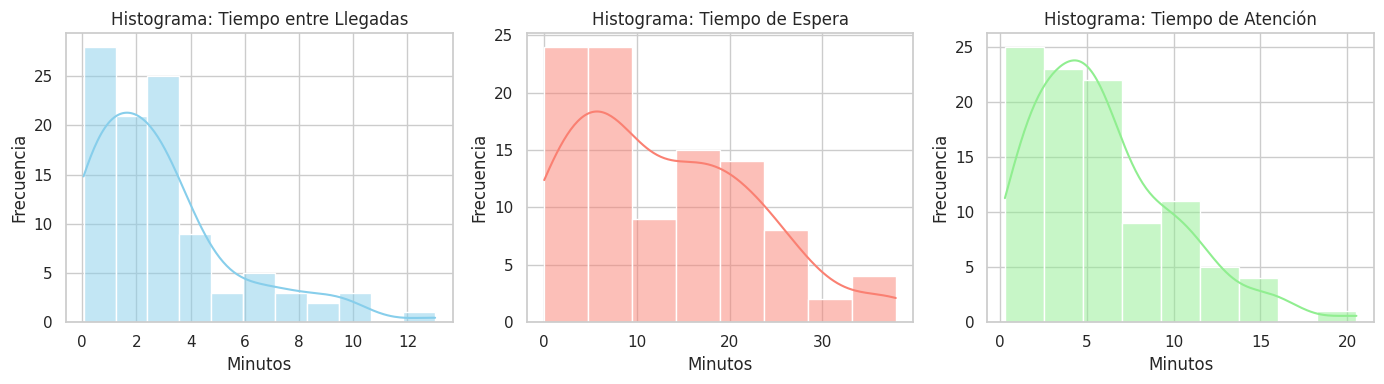

In [ ]:
 #Histogramas
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
sns.histplot(df_cajas['Tiempo entre llegadas (min)'], kde=True, color='skyblue')
plt.title('Histograma: Tiempo entre Llegadas')
plt.xlabel('Minutos')
plt.ylabel('Frecuencia')

plt.subplot(1, 3, 2)
sns.histplot(df_cajas['Tiempo de espera (min)'], kde=True, color='salmon')
plt.title('Histograma: Tiempo de Espera')
plt.xlabel('Minutos')
plt.ylabel('Frecuencia')

plt.subplot(1, 3, 3)
sns.histplot(df_cajas['Tiempo de atencion (min)'], kde=True, color='lightgreen')
plt.title('Histograma: Tiempo de Atención')
plt.xlabel('Minutos')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

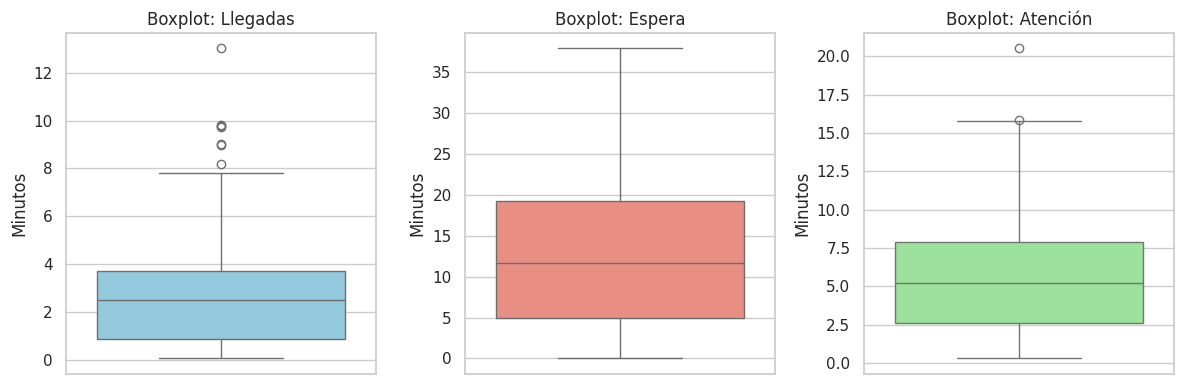

In [ ]:
#Boxplots
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.boxplot(y=df_cajas['Tiempo entre llegadas (min)'], color='skyblue')
plt.title('Boxplot: Llegadas')
plt.ylabel('Minutos')

plt.subplot(1, 3, 2)
sns.boxplot(y=df_cajas['Tiempo de espera (min)'], color='salmon')
plt.title('Boxplot: Espera')
plt.ylabel('Minutos')

plt.subplot(1, 3, 3)
sns.boxplot(y=df_cajas['Tiempo de atencion (min)'], color='lightgreen')
plt.title('Boxplot: Atención')
plt.ylabel('Minutos')

plt.tight_layout()
plt.show()

# PROCESO AS - IS

In [20]:
"""
===========================================================
SIMULACIÓN DE UNA AGENCIA BANCARIA (M/G/c)


Modelo:
- Llegadas: Exponencial (proceso de Poisson -> demanda por hora ~ Poisson)
- Atención: Lognormal
- c Cajeros
- Cola FIFO
- Horario de atención: 9:00 am a 6:00 pm


===========================================================
"""

# ==========================================================
# VARIABLES DE ENTRADA
# ==========================================================

HORA_INICIO = 9
HORA_CIERRE = 18
HORARIO_ATENCION = (HORA_CIERRE - HORA_INICIO) * 60   # 540 minutos

NUMERO_CAJEROS = 2

# Capacidad máxima de la cola/sala INTERNA (personas esperando adentro)
CAPACIDAD_COLA_INTERNA = 6

# --- Llegadas: EXPONENCIAL ---
TIEMPO_ENTRE_LLEGADAS = media_tiempo_llegada

# --- Atención: LOGNORMAL ---
TIEMPO_ATENCION_MEDIA = media_tiempo_atencion
TIEMPO_ATENCION_DESV  = desv_tiempo_atencion

_var = TIEMPO_ATENCION_DESV ** 2
_sigma2 = math.log(1 + (_var / (TIEMPO_ATENCION_MEDIA ** 2)))
SIGMA_LOGNORMAL = math.sqrt(_sigma2)
MU_LOGNORMAL = math.log(TIEMPO_ATENCION_MEDIA) - (_sigma2 / 2)

# Generadores aleatorios independientes (llegadas / atención)
rng_llegadas = random.Random(50)
rng_atencion = random.Random(51)


# ==========================================================
# VARIABLES DE ESTADO
# ==========================================================

longitud_cola_externa = 0
longitud_cola_interna = 0

# ==========================================================
# VARIABLES DE SALIDA
# ==========================================================

numero_clientes_llegaron = 0
numero_clientes_atendidos = 0
numero_clientes_perdidos = 0     # se retiraron sin entrar (cierre)

lista_espera_externa = []        # tiempo esperando afuera hasta entrar
lista_espera_interna = []        # tiempo esperando adentro hasta ser atendido
lista_tiempo_atencion = []
lista_tiempo_sistema = []        # tiempo total desde que llegó hasta que salió

# ==========================================================
# VARIABLES AUXILIARES PARA INDICADORES (áreas bajo la curva)
# ==========================================================

area_cola_externa = 0.0
area_cola_interna = 0.0
ultimo_evento_externa = 0.0
ultimo_evento_interna = 0.0

tiempo_ocupado_total = 0.0


# ==========================================================
# CONVERSIÓN DE MINUTOS DE SIMULACIÓN A HORA REAL
# ==========================================================

def hora_real(minutos_simulacion):
    total_minutos = int(HORA_INICIO * 60 + minutos_simulacion)
    horas = total_minutos // 60
    minutos = total_minutos % 60
    return f"{horas:02d}:{minutos:02d}"


# ==========================================================
# ACTUALIZAR ÁREAS DE LAS COLAS (para promedio de longitud)
# ==========================================================

def actualizar_area_externa(env):
    global area_cola_externa, ultimo_evento_externa
    tiempo = env.now - ultimo_evento_externa
    area_cola_externa += longitud_cola_externa * tiempo
    ultimo_evento_externa = env.now

def actualizar_area_interna(env):
    global area_cola_interna, ultimo_evento_interna
    tiempo = env.now - ultimo_evento_interna
    area_cola_interna += longitud_cola_interna * tiempo
    ultimo_evento_interna = env.now


# ==========================================================
# PROCESO CLIENTE
# ==========================================================

def cliente(env, nombre, sala_interna, cajeros):

    global numero_clientes_atendidos
    global numero_clientes_perdidos
    global tiempo_ocupado_total
    global longitud_cola_externa
    global longitud_cola_interna

    llegada = env.now

    print(f"{hora_real(env.now)} -> {nombre} llega y entra a la cola EXTERNA")

    actualizar_area_externa(env)
    longitud_cola_externa += 1

    # Tiempo restante hasta el cierre oficial; si se agota antes de
    # conseguir un cupo interno, el cliente se retira sin ser atendido.
    tiempo_restante = max(0, HORARIO_ATENCION - env.now)

    with sala_interna.request() as solicitud_interna:

        resultado = yield solicitud_interna | env.timeout(tiempo_restante)

        actualizar_area_externa(env)
        longitud_cola_externa -= 1

        if solicitud_interna not in resultado:
            # Se cerró antes de conseguir un cupo interno: se va sin atención
            numero_clientes_perdidos += 1
            print(
                f"{hora_real(env.now)} -> {nombre} se RETIRA sin ser atendido "
                f"(cierre; seguía en la cola externa)"
            )
            return

        # ---- Consiguió un cupo en la cola/sala INTERNA ----
        entrada_interna = env.now
        espera_externa = entrada_interna - llegada
        lista_espera_externa.append(espera_externa)

        actualizar_area_interna(env)
        longitud_cola_interna += 1

        print(f"{hora_real(env.now)} -> {nombre} entra a la cola INTERNA")

        with cajeros.request() as solicitud_cajero:

            yield solicitud_cajero

            actualizar_area_interna(env)
            longitud_cola_interna -= 1

            inicio_atencion = env.now
            espera_interna = inicio_atencion - entrada_interna
            lista_espera_interna.append(espera_interna)

            print(f"{hora_real(env.now)} -> {nombre} inicia atención")

            servicio = rng_atencion.lognormvariate(MU_LOGNORMAL, SIGMA_LOGNORMAL)
            lista_tiempo_atencion.append(servicio)
            tiempo_ocupado_total += servicio

            yield env.timeout(servicio)

            numero_clientes_atendidos += 1
            lista_tiempo_sistema.append(env.now - llegada)

            print(f"{hora_real(env.now)} -> {nombre} sale")

        # Al salir de este 'with', se libera el cupo de la sala interna
        # automáticamente, permitiendo que otro cliente de la cola
        # externa pueda entrar (si todavía no ha cerrado).


# ==========================================================
# GENERADOR DE CLIENTES
# ==========================================================

def llegadas(env, sala_interna, cajeros):

    global numero_clientes_llegaron
    contador = 1

    while True:
        tiempo = rng_llegadas.expovariate(1 / TIEMPO_ENTRE_LLEGADAS)

        # No se generan más llegadas después de la hora de cierre
        if env.now + tiempo >= HORARIO_ATENCION:
            break

        yield env.timeout(tiempo)

        numero_clientes_llegaron += 1

        env.process(cliente(env, f"Cliente {contador}", sala_interna, cajeros))

        contador += 1


# ==========================================================
# EJECUCIÓN
# ==========================================================

env = simpy.Environment()

# Recurso que representa los 6 cupos físicos de la sala interna
sala_interna = simpy.Resource(env, capacity=CAPACIDAD_COLA_INTERNA)

# Recurso que representa los cajeros
cajeros = simpy.Resource(env, capacity=NUMERO_CAJEROS)

env.process(llegadas(env, sala_interna, cajeros))

# Sin límite fijo: termina cuando ya no hay más llegadas posibles
# Y todos los que entraron a la sala interna ya fueron atendidos.
env.run()

tiempo_total_operacion = env.now
minutos_extra = max(0, tiempo_total_operacion - HORARIO_ATENCION)


09:01 -> Cliente 1 llega y entra a la cola EXTERNA
09:01 -> Cliente 1 entra a la cola INTERNA
09:01 -> Cliente 1 inicia atención
09:02 -> Cliente 2 llega y entra a la cola EXTERNA
09:02 -> Cliente 2 entra a la cola INTERNA
09:02 -> Cliente 2 inicia atención
09:04 -> Cliente 1 sale
09:05 -> Cliente 2 sale
09:05 -> Cliente 3 llega y entra a la cola EXTERNA
09:05 -> Cliente 3 entra a la cola INTERNA
09:05 -> Cliente 3 inicia atención
09:06 -> Cliente 4 llega y entra a la cola EXTERNA
09:06 -> Cliente 4 entra a la cola INTERNA
09:06 -> Cliente 4 inicia atención
09:08 -> Cliente 5 llega y entra a la cola EXTERNA
09:08 -> Cliente 5 entra a la cola INTERNA
09:12 -> Cliente 4 sale
09:12 -> Cliente 5 inicia atención
09:16 -> Cliente 3 sale
09:17 -> Cliente 5 sale
09:18 -> Cliente 6 llega y entra a la cola EXTERNA
09:18 -> Cliente 6 entra a la cola INTERNA
09:18 -> Cliente 6 inicia atención
09:18 -> Cliente 7 llega y entra a la cola EXTERNA
09:18 -> Cliente 7 entra a la cola INTERNA
09:18 -> Cli

In [21]:

# ==========================================================
# INDICADORES DE DESEMPEÑO
# ==========================================================

print("\n")
print("="*65)
print("INDICADORES DE DESEMPEÑO")
print("="*65)

promedio_espera_externa = (
    sum(lista_espera_externa) / len(lista_espera_externa)
) if lista_espera_externa else 0

promedio_espera_interna = (
    sum(lista_espera_interna) / len(lista_espera_interna)
) if lista_espera_interna else 0

promedio_atencion = (
    sum(lista_tiempo_atencion) / len(lista_tiempo_atencion)
) if lista_tiempo_atencion else 0

promedio_sistema = (
    sum(lista_tiempo_sistema) / len(lista_tiempo_sistema)
) if lista_tiempo_sistema else 0

cola_externa_promedio = area_cola_externa / tiempo_total_operacion
cola_interna_promedio = area_cola_interna / tiempo_total_operacion

utilizacion = (
    tiempo_ocupado_total / (NUMERO_CAJEROS * tiempo_total_operacion)
) * 100

clientes_hora = numero_clientes_atendidos / (tiempo_total_operacion / 60)

print(f"Horario oficial                  : {HORA_INICIO}:00 - {HORA_CIERRE}:00")
print(f"Capacidad de la cola interna     : {CAPACIDAD_COLA_INTERNA} personas")
print(f"Clientes que llegaron            : {numero_clientes_llegaron}")
print(f"Clientes atendidos               : {numero_clientes_atendidos}")
print(f"Clientes perdidos (cierre)       : {numero_clientes_perdidos}")
print(f"Tiempo promedio espera EXTERNA   : {promedio_espera_externa:.2f} min")
print(f"Tiempo promedio espera INTERNA   : {promedio_espera_interna:.2f} min")
print(f"Tiempo promedio de atención      : {promedio_atencion:.2f} min")
print(f"Tiempo promedio en el sistema     : {promedio_sistema:.2f} min")
print(f"Longitud promedio cola EXTERNA   : {cola_externa_promedio:.2f} personas")
print(f"Longitud promedio cola INTERNA   : {cola_interna_promedio:.2f} personas "
      f"(máx. {CAPACIDAD_COLA_INTERNA})")
print(f"Utilización de cajeros           : {utilizacion:.2f}%")
print(f"Clientes atendidos por hora      : {clientes_hora:.2f}")
print(f"Hora real del último cliente     : {hora_real(tiempo_total_operacion)}")
print(f"Minutos extra tras el cierre     : {minutos_extra:.2f} min")

print("="*65)



INDICADORES DE DESEMPEÑO
Horario oficial                  : 9:00 - 18:00
Capacidad de la cola interna     : 6 personas
Clientes que llegaron            : 193
Clientes atendidos               : 184
Clientes perdidos (cierre)       : 9
Tiempo promedio espera EXTERNA   : 8.16 min
Tiempo promedio espera INTERNA   : 8.33 min
Tiempo promedio de atención      : 5.55 min
Tiempo promedio en el sistema     : 22.04 min
Longitud promedio cola EXTERNA   : 2.90 personas
Longitud promedio cola INTERNA   : 2.76 personas (máx. 6)
Utilización de cajeros           : 92.10%
Clientes atendidos por hora      : 19.91
Hora real del último cliente     : 18:14
Minutos extra tras el cierre     : 14.36 min


# ESCENARIOS WHAT - IF

In [ ]:
# ==========================================================
# ANÁLISIS DE ESCENARIOS WHAT-IF (MODELO CON SALA INTERNA Y CAJEROS)
# ==========================================================

def ejecutar_what_if(cajeros_test, capacidad_interna_test):
    env_w = simpy.Environment()
    sala_interna_w = simpy.Resource(env_w, capacity=capacidad_interna_test)
    cajeros_w = simpy.Resource(env_w, capacity=cajeros_test)

    # Listas y métricas locales
    l_espera_ext = []
    l_espera_int = []
    l_atencion = []
    l_sistema = []

    t_ocupado_w = 0.0
    area_ext = 0.0
    area_int = 0.0
    ult_ext = 0.0
    ult_int = 0.0

    long_ext = 0
    long_int = 0

    n_llegaron = 0
    n_atendidos = 0
    n_perdidos = 0

    def actualizar_areas_w(env):
        nonlocal area_ext, area_int, ult_ext, ult_int, long_ext, long_int
        t_ext = env.now - ult_ext
        area_ext += long_ext * t_ext
        ult_ext = env.now

        t_int = env.now - ult_int
        area_int += long_int * t_int
        ult_int = env.now

    def cliente_w(env, nombre):
        nonlocal n_atendidos, n_perdidos, t_ocupado_w, long_ext, long_int
        llegada = env.now

        actualizar_areas_w(env)
        long_ext += 1

        tiempo_restante = max(0, HORARIO_ATENCION - env.now)

        with sala_interna_w.request() as req_int:
            res_int = yield req_int | env.timeout(tiempo_restante)

            actualizar_areas_w(env)
            long_ext -= 1

            if req_int not in res_int:
                n_perdidos += 1
                return

            entrada_int = env.now
            l_espera_ext.append(entrada_int - llegada)

            actualizar_areas_w(env)
            long_int += 1

            with cajeros_w.request() as req_caj:
                yield req_caj

                actualizar_areas_w(env)
                long_int -= 1

                inicio_at = env.now
                l_espera_int.append(inicio_at - entrada_int)

                servicio = rng_atencion_w.lognormvariate(MU_LOGNORMAL, SIGMA_LOGNORMAL)
                l_atencion.append(servicio)
                t_ocupado_w += servicio

                yield env.timeout(servicio)

                n_atendidos += 1
                l_sistema.append(env.now - llegada)

    def llegadas_w(env):
        nonlocal n_llegaron
        contador = 1
        while True:
            tiempo = rng_llegadas_w.expovariate(1 / TIEMPO_ENTRE_LLEGADAS)
            if env.now + tiempo >= HORARIO_ATENCION:
                break
            yield env.timeout(tiempo)
            n_llegaron += 1
            env.process(cliente_w(env, f"Cliente {contador}"))
            contador += 1

    # Semillas independientes idénticas para una comparación justa
    rng_llegadas_w = random.Random(50)
    rng_atencion_w = random.Random(51)

    env_w.process(llegadas_w(env_w))
    env_w.run()

    t_total = env_w.now

    # Cálculo de indicadores
    p_esp_ext = sum(l_espera_ext) / len(l_espera_ext) if l_espera_ext else 0
    p_esp_int = sum(l_espera_int) / len(l_espera_int) if l_espera_int else 0
    p_at = sum(l_atencion) / len(l_atencion) if l_atencion else 0
    p_sis = sum(l_sistema) / len(l_sistema) if l_sistema else 0
    c_ext_prom = area_ext / t_total
    c_int_prom = area_int / t_total
    util_w = (t_ocupado_w / (cajeros_test * t_total)) * 100

    return {
        "Cajeros": cajeros_test,
        "Sala Int.": capacidad_interna_test,
        "Atendidos": n_atendidos,
        "Perdidos": n_perdidos,
        "Espr.Ext (min)": round(p_esp_ext, 2),
        "Espr.Int (min)": round(p_esp_int, 2),
        "Cola Ext": round(c_ext_prom, 2),
        "Cola Int": round(c_int_prom, 2),
        "Utilización (%)": round(util_w, 2),
        "Cierre Real": hora_real(t_total)
    }

# Definimos los escenarios a probar (Escenario base: 2 cajeros / 6 internos, y alternativas What-If)
escenarios = [
    {"cajeros": 2, "interna": 6},  # AS-IS actual
    {"cajeros": 4, "interna": 10},  # What-If - Optimista: Aumentar a 4 cajeros y capacidad aumentada
    {"cajeros": 3, "interna": 6},  # What-If - Normal (TO-BE) : Aumentar a 3 cajeros
    {"cajeros": 1, "interna": 6}   # What-If - Pesimista (Sobrecarga): 1 cajeros
]

resultados_wi = [ejecutar_what_if(e["cajeros"], e["interna"]) for e in escenarios]

df_what_if_avanzado = pd.DataFrame(resultados_wi)

print("\n")
print("="*105)
print(f"{'TABLA COMPARATIVA: ESCENARIOS WHAT-IF ':^105}")
print("="*105)
display(df_what_if_avanzado)
print("="*105)



                                 TABLA COMPARATIVA: ESCENARIOS WHAT-IF                                   


,Cajeros,Sala Int.,Atendidos,Perdidos,Espr.Ext (min),Espr.Int (min),Cola Ext,Cola Int,Utilización (%),Cierre Real
0,2,6,184,9,8.16,8.33,2.90,2.76,92.10,18:14
1,4,10,193,0,0.00,0.45,0.00,0.16,49.27,18:04
2,3,6,193,0,0.13,1.46,0.05,0.52,65.53,18:06
3,1,6,100,93,90.71,27.05,35.25,4.64,99.66,18:42


# PROCESO TO - BE

In [ ]:
"""
===========================================================
SIMULACIÓN DE UNA AGENCIA BANCARIA - DOS COLAS
Horario de cajeros:
  - Cajero 1: 9:00 am - 6:00 pm (almuerzo 1:00 - 2:00 pm)
  - Cajero 2: 9:00 am - 6:00 pm (almuerzo 2:00 - 3:00 pm)
  - Cajero 3: 1:00 pm - 6:00 pm (turno corto, sin almuerzo)
===========================================================
"""


rng_llegadas = random.Random(50)
rng_atencion = random.Random(51)
# ==========================================================
# HORARIO DE CAJEROS (en minutos desde HORA_INICIO)
# ==========================================================
EVENTOS_CAJEROS = [
    (0,   +1, "Cajero 1 inicia turno (9:00 am)"),
    (0,   +1, "Cajero 2 inicia turno (9:00 am)"),
    (240, -1, "Cajero 1 sale a almorzar (1:00 pm)"),
    (240, +1, "Cajero 3 inicia turno de refuerzo (1:00 pm)"),
    (300, +1, "Cajero 1 vuelve de almorzar (2:00 pm)"),
    (300, -1, "Cajero 2 sale a almorzar (2:00 pm)"),
    (360, +1, "Cajero 2 vuelve de almorzar (3:00 pm)"),
]
# Capacidad inicial en t=0 (antes de aplicar el primer evento)
CAPACIDAD_INICIAL_CAJEROS = 0

# ==========================================================
# VARIABLES DE ESTADO
# ==========================================================

longitud_cola_externa = 0
longitud_cola_interna = 0

# ==========================================================
# VARIABLES DE SALIDA
# ==========================================================

numero_clientes_llegaron = 0
numero_clientes_atendidos = 0
numero_clientes_perdidos = 0

lista_espera_externa = []
lista_espera_interna = []
lista_tiempo_atencion = []
lista_tiempo_sistema = []

# ==========================================================
# VARIABLES AUXILIARES (áreas bajo la curva)
# ==========================================================

area_cola_externa = 0.0
area_cola_interna = 0.0
ultimo_evento_externa = 0.0
ultimo_evento_interna = 0.0

tiempo_ocupado_total = 0.0

area_capacidad_cajeros = 0.0
ultimo_evento_capacidad = 0.0
capacidad_actual_cajeros = CAPACIDAD_INICIAL_CAJEROS


# ==========================================================
# CONVERSIÓN DE MINUTOS A HORA REAL
# ==========================================================

def hora_real(minutos_simulacion):
    total_minutos = int(HORA_INICIO * 60 + minutos_simulacion)
    horas = total_minutos // 60
    minutos = total_minutos % 60
    return f"{horas:02d}:{minutos:02d}"


# ==========================================================
# ACTUALIZAR ÁREAS
# ==========================================================

def actualizar_area_externa(env):
    global area_cola_externa, ultimo_evento_externa
    tiempo = env.now - ultimo_evento_externa
    area_cola_externa += longitud_cola_externa * tiempo
    ultimo_evento_externa = env.now

def actualizar_area_interna(env):
    global area_cola_interna, ultimo_evento_interna
    tiempo = env.now - ultimo_evento_interna
    area_cola_interna += longitud_cola_interna * tiempo
    ultimo_evento_interna = env.now

def actualizar_area_capacidad(env):
    global area_capacidad_cajeros, ultimo_evento_capacidad
    tiempo = env.now - ultimo_evento_capacidad
    area_capacidad_cajeros += capacidad_actual_cajeros * tiempo
    ultimo_evento_capacidad = env.now


# ==========================================================
# PROCESO: HORARIO DE CAJEROS (turnos + almuerzos)
# ==========================================================

def controlar_horario_cajeros(env, cajeros):
    """Aplica los cambios de capacidad de cajeros según los turnos
    y horarios de almuerzo definidos en EVENTOS_CAJEROS."""

    global capacidad_actual_cajeros

    tiempo_actual = 0
    for minuto_evento, delta, descripcion in EVENTOS_CAJEROS:
        espera = minuto_evento - tiempo_actual
        if espera > 0:
            yield env.timeout(espera)
        tiempo_actual = minuto_evento

        actualizar_area_capacidad(env)
        cajeros._capacity += delta
        capacidad_actual_cajeros = cajeros._capacity

        print(f"{hora_real(env.now)} -> {descripcion} "
              f"(cajeros activos: {cajeros._capacity})")

        if delta > 0:
            # Si aumentó la capacidad, revisa la cola de espera de cajero
            cajeros._trigger_put(None)


# ==========================================================
# PROCESO CLIENTE
# ==========================================================

def cliente(env, nombre, sala_interna, cajeros):

    global numero_clientes_atendidos
    global numero_clientes_perdidos
    global tiempo_ocupado_total
    global longitud_cola_externa
    global longitud_cola_interna

    llegada = env.now

    print(f"{hora_real(env.now)} -> {nombre} llega y entra a la cola EXTERNA")

    actualizar_area_externa(env)
    longitud_cola_externa += 1

    tiempo_restante = max(0, HORARIO_ATENCION - env.now)

    with sala_interna.request() as solicitud_interna:

        resultado = yield solicitud_interna | env.timeout(tiempo_restante)

        actualizar_area_externa(env)
        longitud_cola_externa -= 1

        if solicitud_interna not in resultado:
            numero_clientes_perdidos += 1
            print(
                f"{hora_real(env.now)} -> {nombre} se RETIRA sin ser atendido "
                f"(cierre; seguía en la cola externa)"
            )
            return

        entrada_interna = env.now
        espera_externa = entrada_interna - llegada
        lista_espera_externa.append(espera_externa)

        actualizar_area_interna(env)
        longitud_cola_interna += 1

        print(f"{hora_real(env.now)} -> {nombre} entra a la cola INTERNA")

        with cajeros.request() as solicitud_cajero:

            yield solicitud_cajero

            actualizar_area_interna(env)
            longitud_cola_interna -= 1

            inicio_atencion = env.now
            espera_interna = inicio_atencion - entrada_interna
            lista_espera_interna.append(espera_interna)

            print(f"{hora_real(env.now)} -> {nombre} inicia atención")

            servicio = rng_atencion.lognormvariate(MU_LOGNORMAL, SIGMA_LOGNORMAL)
            lista_tiempo_atencion.append(servicio)
            tiempo_ocupado_total += servicio

            yield env.timeout(servicio)

            numero_clientes_atendidos += 1
            lista_tiempo_sistema.append(env.now - llegada)

            print(f"{hora_real(env.now)} -> {nombre} sale")


# ==========================================================
# GENERADOR DE CLIENTES
# ==========================================================

def llegadas(env, sala_interna, cajeros):

    global numero_clientes_llegaron
    contador = 1

    while True:
        tiempo = rng_llegadas.expovariate(1 / TIEMPO_ENTRE_LLEGADAS)

        if env.now + tiempo >= HORARIO_ATENCION:
            break

        yield env.timeout(tiempo)

        numero_clientes_llegaron += 1

        env.process(cliente(env, f"Cliente {contador}", sala_interna, cajeros))

        contador += 1


# ==========================================================
# EJECUCIÓN
# ==========================================================

env = simpy.Environment()

sala_interna = simpy.Resource(env, capacity=CAPACIDAD_COLA_INTERNA)

# Cajeros arranca en 0 y el proceso de horario le va sumando/restando
# capacidad según los turnos y almuerzos definidos arriba
cajeros = simpy.Resource(env, capacity=CAPACIDAD_INICIAL_CAJEROS or 1)
cajeros._capacity = CAPACIDAD_INICIAL_CAJEROS  # forzar arranque en 0

env.process(llegadas(env, sala_interna, cajeros))
env.process(controlar_horario_cajeros(env, cajeros))

env.run()

tiempo_total_operacion = env.now
minutos_extra = max(0, tiempo_total_operacion - HORARIO_ATENCION)

actualizar_area_capacidad(env)


09:00 -> Cajero 1 inicia turno (9:00 am) (cajeros activos: 1)
09:00 -> Cajero 2 inicia turno (9:00 am) (cajeros activos: 2)
09:01 -> Cliente 1 llega y entra a la cola EXTERNA
09:01 -> Cliente 1 entra a la cola INTERNA
09:01 -> Cliente 1 inicia atención
09:02 -> Cliente 2 llega y entra a la cola EXTERNA
09:02 -> Cliente 2 entra a la cola INTERNA
09:02 -> Cliente 2 inicia atención
09:04 -> Cliente 1 sale
09:05 -> Cliente 2 sale
09:05 -> Cliente 3 llega y entra a la cola EXTERNA
09:05 -> Cliente 3 entra a la cola INTERNA
09:05 -> Cliente 3 inicia atención
09:06 -> Cliente 4 llega y entra a la cola EXTERNA
09:06 -> Cliente 4 entra a la cola INTERNA
09:06 -> Cliente 4 inicia atención
09:08 -> Cliente 5 llega y entra a la cola EXTERNA
09:08 -> Cliente 5 entra a la cola INTERNA
09:12 -> Cliente 4 sale
09:12 -> Cliente 5 inicia atención
09:16 -> Cliente 3 sale
09:17 -> Cliente 5 sale
09:18 -> Cliente 6 llega y entra a la cola EXTERNA
09:18 -> Cliente 6 entra a la cola INTERNA
09:18 -> Cliente 

In [ ]:

# ==========================================================
# INDICADORES DE DESEMPEÑO
# ==========================================================

print("\n")
print("="*65)
print("INDICADORES DE DESEMPEÑO")
print("="*65)

promedio_espera_externa = (
    sum(lista_espera_externa) / len(lista_espera_externa)
) if lista_espera_externa else 0

promedio_espera_interna = (
    sum(lista_espera_interna) / len(lista_espera_interna)
) if lista_espera_interna else 0

promedio_atencion = (
    sum(lista_tiempo_atencion) / len(lista_tiempo_atencion)
) if lista_tiempo_atencion else 0

promedio_sistema = (
    sum(lista_tiempo_sistema) / len(lista_tiempo_sistema)
) if lista_tiempo_sistema else 0

cola_externa_promedio = area_cola_externa / tiempo_total_operacion
cola_interna_promedio = area_cola_interna / tiempo_total_operacion

utilizacion = (
    tiempo_ocupado_total / area_capacidad_cajeros
) * 100 if area_capacidad_cajeros > 0 else 0

promedio_cajeros_activos = area_capacidad_cajeros / tiempo_total_operacion

clientes_hora = numero_clientes_atendidos / (tiempo_total_operacion / 60)

print(f"Horario oficial                  : {HORA_INICIO}:00 - {HORA_CIERRE}:00")
print("Turnos de cajeros:")
print("  Cajero 1: 9:00 am - 6:00 pm (almuerzo 1:00 - 2:00 pm)")
print("  Cajero 2: 9:00 am - 6:00 pm (almuerzo 2:00 - 3:00 pm)")
print("  Cajero 3: 1:00 pm - 6:00 pm (sin almuerzo)")
print(f"Capacidad de la cola interna     : {CAPACIDAD_COLA_INTERNA} personas")
print(f"Clientes que llegaron            : {numero_clientes_llegaron}")
print(f"Clientes atendidos               : {numero_clientes_atendidos}")
print(f"Clientes perdidos (cierre)       : {numero_clientes_perdidos}")
print(f"Tiempo promedio espera EXTERNA   : {promedio_espera_externa:.2f} min")
print(f"Tiempo promedio espera INTERNA   : {promedio_espera_interna:.2f} min")
print(f"Tiempo promedio de atención      : {promedio_atencion:.2f} min")
print(f"Tiempo promedio en el sistema     : {promedio_sistema:.2f} min")
print(f"Longitud promedio cola EXTERNA   : {cola_externa_promedio:.2f} personas")
print(f"Longitud promedio cola INTERNA   : {cola_interna_promedio:.2f} personas "
      f"(máx. {CAPACIDAD_COLA_INTERNA})")
print(f"Promedio de cajeros activos      : {promedio_cajeros_activos:.2f}")
print(f"Utilización de cajeros           : {utilizacion:.2f}%")
print(f"Clientes atendidos por hora      : {clientes_hora:.2f}")
print(f"Hora real del último cliente     : {hora_real(tiempo_total_operacion)}")
print(f"Minutos extra tras el cierre     : {minutos_extra:.2f} min")

print("="*65)



INDICADORES DE DESEMPEÑO
Horario oficial                  : 9:00 - 18:00
Turnos de cajeros:
  Cajero 1: 9:00 am - 6:00 pm (almuerzo 1:00 - 2:00 pm)
  Cajero 2: 9:00 am - 6:00 pm (almuerzo 2:00 - 3:00 pm)
  Cajero 3: 1:00 pm - 6:00 pm (sin almuerzo)
Capacidad de la cola interna     : 6 personas
Clientes que llegaron            : 193
Clientes atendidos               : 193
Clientes perdidos (cierre)       : 0
Tiempo promedio espera EXTERNA   : 3.37 min
Tiempo promedio espera INTERNA   : 5.16 min
Tiempo promedio de atención      : 5.56 min
Tiempo promedio en el sistema     : 14.09 min
Longitud promedio cola EXTERNA   : 1.19 personas
Longitud promedio cola INTERNA   : 1.82 personas (máx. 6)
Promedio de cajeros activos      : 2.34
Utilización de cajeros           : 83.98%
Clientes atendidos por hora      : 21.20
Hora real del último cliente     : 18:06
Minutos extra tras el cierre     : 6.23 min


#Graficos comparacion AS IS - TO BE


TABLA RESUMEN COMPARATIVA (As-Is vs. To-Be)
                                    nombre         descripcion_cajeros  promedio_cajeros_activos  capacidad_interna  clientes_llegaron  clientes_atendidos  clientes_perdidos  espera_externa_prom  espera_interna_prom  espera_total_prom  atencion_prom  sistema_prom  cola_externa_prom  cola_interna_prom  utilizacion_pct  clientes_por_hora hora_ultimo_cliente  minutos_extra
   As-Is: 2 cajeros fijos / cupo interno 6                     2 fijos                      2.00                  6                193                 184                  9                 8.21                 8.33              16.53           5.55         22.08               2.92               2.76            92.12              19.92               18:14          14.30
To-Be: cajeros por turnos / cupo interno 6 Turnos (2-3, con almuerzos)                      2.34                  6                193                 193                  0                 3.39                

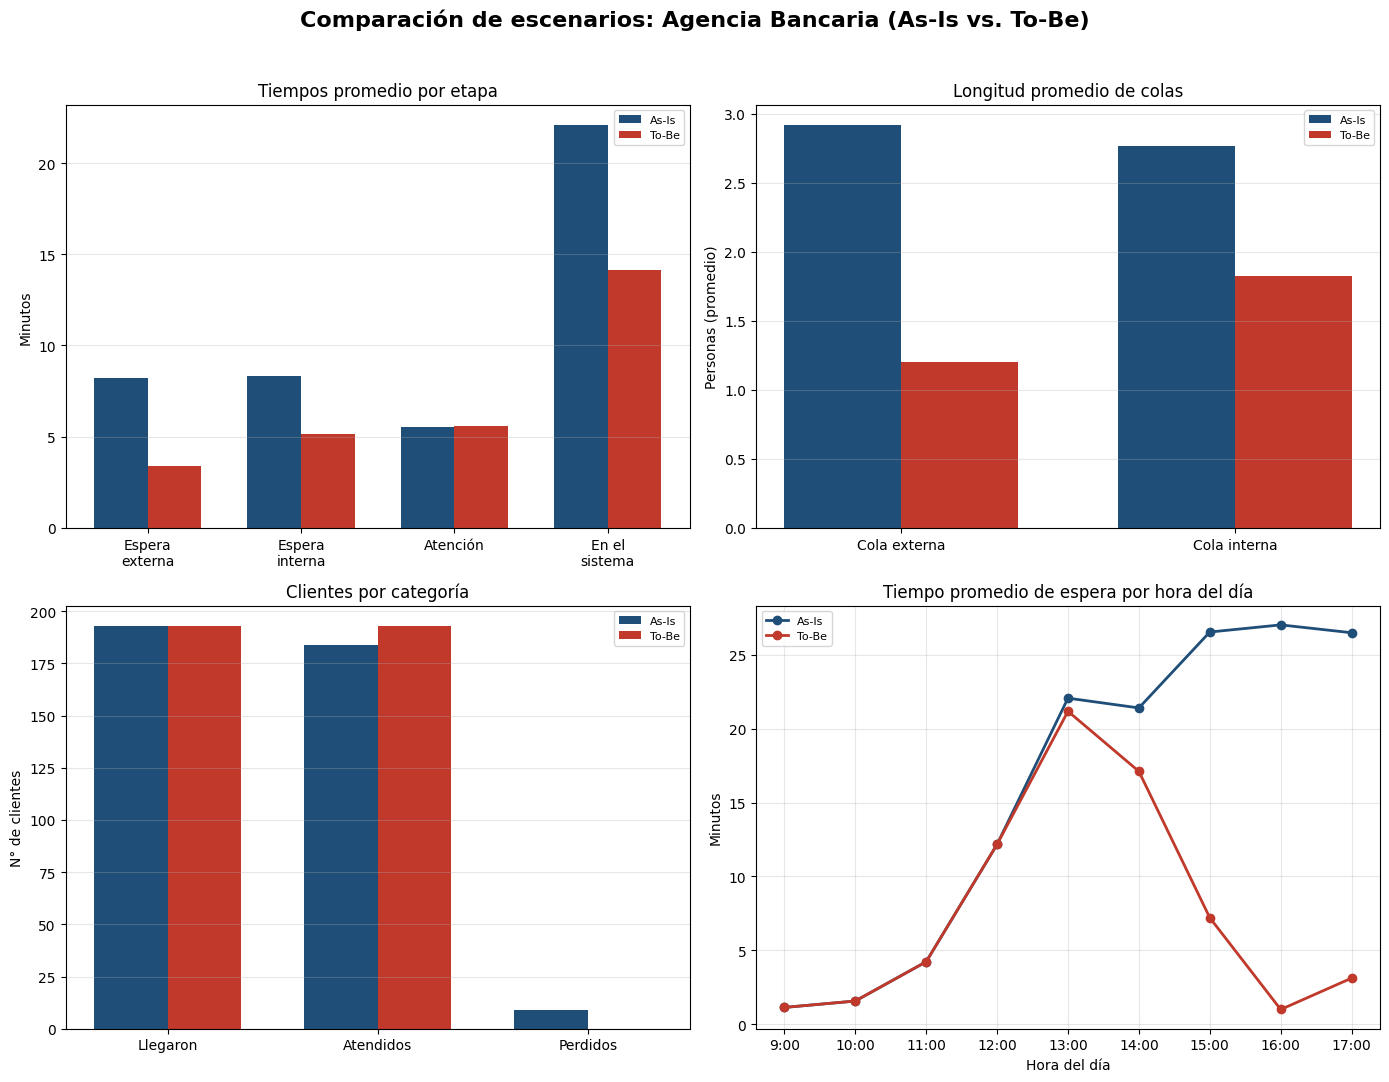

In [ ]:
"""
===========================================================
SIMULACIÓN COMPARATIVA DE UNA AGENCIA BANCARIA
===========================================================
"""

# ==========================================================
# FUNCIÓN 1: CAJEROS CON CAPACIDAD FIJA (usada para "As-Is")
# ==========================================================

def ejecutar_simulacion(nombre_escenario, num_cajeros, capacidad_interna,
                         hora_inicio=9, hora_cierre=18,
                         tiempo_entre_llegadas=2.88,
                         tiempo_atencion_media=5.848,
                         tiempo_atencion_desv=4.044,
                         seed_llegadas=50, seed_atencion=51,
                         verbose=False):

    horario_atencion = (hora_cierre - hora_inicio) * 60

    var = tiempo_atencion_desv ** 2
    sigma2 = math.log(1 + (var / (tiempo_atencion_media ** 2)))
    sigma = math.sqrt(sigma2)
    mu = math.log(tiempo_atencion_media) - (sigma2 / 2)

    rng_llegadas = random.Random(seed_llegadas)
    rng_atencion = random.Random(seed_atencion)

    estado = {
        "longitud_cola_externa": 0,
        "longitud_cola_interna": 0,
        "numero_clientes_llegaron": 0,
        "numero_clientes_atendidos": 0,
        "numero_clientes_perdidos": 0,
        "lista_espera_externa": [],
        "lista_espera_interna": [],
        "lista_tiempo_atencion": [],
        "lista_tiempo_sistema": [],
        "registro_clientes": [],
        "area_cola_externa": 0.0,
        "area_cola_interna": 0.0,
        "ultimo_evento_externa": 0.0,
        "ultimo_evento_interna": 0.0,
        "tiempo_ocupado_total": 0.0,
        "ultima_hora_llegada": None,
    }
    cajero_libre = [True] * num_cajeros

    def hora_real(minutos_simulacion):
        total_minutos = int(hora_inicio * 60 + minutos_simulacion)
        h = total_minutos // 60
        m = total_minutos % 60
        return f"{h:02d}:{m:02d}"

    def actualizar_area_externa(env):
        t = env.now - estado["ultimo_evento_externa"]
        estado["area_cola_externa"] += estado["longitud_cola_externa"] * t
        estado["ultimo_evento_externa"] = env.now

    def actualizar_area_interna(env):
        t = env.now - estado["ultimo_evento_interna"]
        estado["area_cola_interna"] += estado["longitud_cola_interna"] * t
        estado["ultimo_evento_interna"] = env.now

    def tomar_cajero_libre():
        for i in range(num_cajeros):
            if cajero_libre[i]:
                cajero_libre[i] = False
                return i + 1
        return None

    def liberar_cajero(n):
        cajero_libre[n - 1] = True

    def cliente(env, nombre, sala_interna, cajeros):
        llegada = env.now

        if estado["ultima_hora_llegada"] is None:
            tiempo_entre_obs = 0.0
        else:
            tiempo_entre_obs = llegada - estado["ultima_hora_llegada"]
        estado["ultima_hora_llegada"] = llegada

        if verbose:
            print(f"{hora_real(env.now)} -> {nombre} llega y entra a la cola EXTERNA")

        actualizar_area_externa(env)
        estado["longitud_cola_externa"] += 1

        tiempo_restante = max(0, horario_atencion - env.now)

        with sala_interna.request() as solicitud_interna:
            resultado = yield solicitud_interna | env.timeout(tiempo_restante)

            actualizar_area_externa(env)
            estado["longitud_cola_externa"] -= 1

            if solicitud_interna not in resultado:
                estado["numero_clientes_perdidos"] += 1
                estado["registro_clientes"].append({
                    "Cliente": nombre,
                    "Hora de llegada": hora_real(llegada),
                    "Tiempo entre llegadas (min)": round(tiempo_entre_obs, 2),
                    "Cajero": "No atendido (cierre)",
                    "Tiempo de espera (min)": None,
                    "Tiempo de atencion (min)": None,
                })
                return

            entrada_interna = env.now
            espera_externa = entrada_interna - llegada
            estado["lista_espera_externa"].append(espera_externa)

            actualizar_area_interna(env)
            estado["longitud_cola_interna"] += 1

            with cajeros.request() as solicitud_cajero:
                yield solicitud_cajero

                actualizar_area_interna(env)
                estado["longitud_cola_interna"] -= 1

                inicio_atencion = env.now
                espera_interna = inicio_atencion - entrada_interna
                estado["lista_espera_interna"].append(espera_interna)

                numero_cajero = tomar_cajero_libre()

                servicio = rng_atencion.lognormvariate(mu, sigma)
                estado["lista_tiempo_atencion"].append(servicio)
                estado["tiempo_ocupado_total"] += servicio

                yield env.timeout(servicio)

                estado["numero_clientes_atendidos"] += 1
                estado["lista_tiempo_sistema"].append(env.now - llegada)

                liberar_cajero(numero_cajero)

                espera_total = espera_externa + espera_interna
                estado["registro_clientes"].append({
                    "Cliente": nombre,
                    "Hora de llegada": hora_real(llegada),
                    "Tiempo entre llegadas (min)": round(tiempo_entre_obs, 2),
                    "Cajero": f"Cajero {numero_cajero}",
                    "Tiempo de espera (min)": round(espera_total, 2),
                    "Tiempo de atencion (min)": round(servicio, 2),
                })

    def llegadas(env, sala_interna, cajeros):
        contador = 1
        while True:
            t = rng_llegadas.expovariate(1 / tiempo_entre_llegadas)
            if env.now + t >= horario_atencion:
                break
            yield env.timeout(t)
            estado["numero_clientes_llegaron"] += 1
            env.process(cliente(env, f"Cliente {contador}", sala_interna, cajeros))
            contador += 1

    env = simpy.Environment()
    sala_interna = simpy.Resource(env, capacity=capacidad_interna)
    cajeros = simpy.Resource(env, capacity=num_cajeros)
    env.process(llegadas(env, sala_interna, cajeros))
    env.run()

    tiempo_total_operacion = env.now
    minutos_extra = max(0, tiempo_total_operacion - horario_atencion)

    def prom(lst):
        return sum(lst) / len(lst) if lst else 0

    resultados = {
        "nombre": nombre_escenario,
        "descripcion_cajeros": f"{num_cajeros} fijos",
        "promedio_cajeros_activos": num_cajeros,
        "capacidad_interna": capacidad_interna,
        "clientes_llegaron": estado["numero_clientes_llegaron"],
        "clientes_atendidos": estado["numero_clientes_atendidos"],
        "clientes_perdidos": estado["numero_clientes_perdidos"],
        "espera_externa_prom": prom(estado["lista_espera_externa"]),
        "espera_interna_prom": prom(estado["lista_espera_interna"]),
        "espera_total_prom": prom([e + i for e, i in zip(
            estado["lista_espera_externa"], estado["lista_espera_interna"])]),
        "atencion_prom": prom(estado["lista_tiempo_atencion"]),
        "sistema_prom": prom(estado["lista_tiempo_sistema"]),
        "cola_externa_prom": estado["area_cola_externa"] / tiempo_total_operacion,
        "cola_interna_prom": estado["area_cola_interna"] / tiempo_total_operacion,
        "utilizacion_pct": (estado["tiempo_ocupado_total"] /
                             (num_cajeros * tiempo_total_operacion)) * 100,
        "clientes_por_hora": estado["numero_clientes_atendidos"] / (tiempo_total_operacion / 60),
        "hora_ultimo_cliente": hora_real(tiempo_total_operacion),
        "minutos_extra": minutos_extra,
        "lista_espera_externa": estado["lista_espera_externa"],
        "lista_espera_interna": estado["lista_espera_interna"],
        "lista_tiempo_atencion": estado["lista_tiempo_atencion"],
        "lista_tiempo_sistema": estado["lista_tiempo_sistema"],
        "registro_clientes": estado["registro_clientes"],
    }
    return resultados


# ==========================================================
# FUNCIÓN 2: CAJEROS CON TURNOS
# ==========================================================

# Eventos por defecto (minuto desde HORA_INICIO, delta de capacidad, descripción)
EVENTOS_CAJEROS_DEFAULT = [
    (0,   +1, "Cajero 1 inicia turno (9:00 am)"),
    (0,   +1, "Cajero 2 inicia turno (9:00 am)"),
    (240, -1, "Cajero 1 sale a almorzar (1:00 pm)"),
    (240, +1, "Cajero 3 inicia turno de refuerzo (1:00 pm)"),
    (300, +1, "Cajero 1 vuelve de almorzar (2:00 pm)"),
    (300, -1, "Cajero 2 sale a almorzar (2:00 pm)"),
    (360, +1, "Cajero 2 vuelve de almorzar (3:00 pm)"),
]


def ejecutar_simulacion_turnos(nombre_escenario, capacidad_interna,
                                eventos_cajeros=None, capacidad_inicial_cajeros=0,
                                hora_inicio=9, hora_cierre=18,
                                tiempo_entre_llegadas=2.88,
                                tiempo_atencion_media=5.848,
                                tiempo_atencion_desv=4.044,
                                seed_llegadas=50, seed_atencion=51,
                                verbose=False):

    if eventos_cajeros is None:
        eventos_cajeros = EVENTOS_CAJEROS_DEFAULT

    horario_atencion = (hora_cierre - hora_inicio) * 60

    var = tiempo_atencion_desv ** 2
    sigma2 = math.log(1 + (var / (tiempo_atencion_media ** 2)))
    sigma = math.sqrt(sigma2)
    mu = math.log(tiempo_atencion_media) - (sigma2 / 2)

    rng_llegadas = random.Random(seed_llegadas)
    rng_atencion = random.Random(seed_atencion)

    estado = {
        "longitud_cola_externa": 0,
        "longitud_cola_interna": 0,
        "numero_clientes_llegaron": 0,
        "numero_clientes_atendidos": 0,
        "numero_clientes_perdidos": 0,
        "lista_espera_externa": [],
        "lista_espera_interna": [],
        "lista_tiempo_atencion": [],
        "lista_tiempo_sistema": [],
        "registro_clientes": [],
        "area_cola_externa": 0.0,
        "area_cola_interna": 0.0,
        "ultimo_evento_externa": 0.0,
        "ultimo_evento_interna": 0.0,
        "tiempo_ocupado_total": 0.0,
        "ultima_hora_llegada": None,
        "area_capacidad_cajeros": 0.0,
        "ultimo_evento_capacidad": 0.0,
        "capacidad_actual_cajeros": capacidad_inicial_cajeros,
    }

    def hora_real(minutos_simulacion):
        total_minutos = int(hora_inicio * 60 + minutos_simulacion)
        h = total_minutos // 60
        m = total_minutos % 60
        return f"{h:02d}:{m:02d}"

    def actualizar_area_externa(env):
        t = env.now - estado["ultimo_evento_externa"]
        estado["area_cola_externa"] += estado["longitud_cola_externa"] * t
        estado["ultimo_evento_externa"] = env.now

    def actualizar_area_interna(env):
        t = env.now - estado["ultimo_evento_interna"]
        estado["area_cola_interna"] += estado["longitud_cola_interna"] * t
        estado["ultimo_evento_interna"] = env.now

    def actualizar_area_capacidad(env):
        t = env.now - estado["ultimo_evento_capacidad"]
        estado["area_capacidad_cajeros"] += estado["capacidad_actual_cajeros"] * t
        estado["ultimo_evento_capacidad"] = env.now

    def controlar_horario_cajeros(env, cajeros):
        """Aplica los cambios de capacidad de cajeros según los turnos
        y horarios de almuerzo definidos en eventos_cajeros."""
        tiempo_actual = 0
        for minuto_evento, delta, descripcion in eventos_cajeros:
            espera = minuto_evento - tiempo_actual
            if espera > 0:
                yield env.timeout(espera)
            tiempo_actual = minuto_evento

            actualizar_area_capacidad(env)
            cajeros._capacity += delta
            estado["capacidad_actual_cajeros"] = cajeros._capacity

            if verbose:
                print(f"{hora_real(env.now)} -> {descripcion} "
                      f"(cajeros activos: {cajeros._capacity})")

            if delta > 0:
                cajeros._trigger_put(None)

    def cliente(env, nombre, sala_interna, cajeros):
        llegada = env.now

        if estado["ultima_hora_llegada"] is None:
            tiempo_entre_obs = 0.0
        else:
            tiempo_entre_obs = llegada - estado["ultima_hora_llegada"]
        estado["ultima_hora_llegada"] = llegada

        if verbose:
            print(f"{hora_real(env.now)} -> {nombre} llega y entra a la cola EXTERNA")

        actualizar_area_externa(env)
        estado["longitud_cola_externa"] += 1

        tiempo_restante = max(0, horario_atencion - env.now)

        with sala_interna.request() as solicitud_interna:
            resultado = yield solicitud_interna | env.timeout(tiempo_restante)

            actualizar_area_externa(env)
            estado["longitud_cola_externa"] -= 1

            if solicitud_interna not in resultado:
                estado["numero_clientes_perdidos"] += 1
                estado["registro_clientes"].append({
                    "Cliente": nombre,
                    "Hora de llegada": hora_real(llegada),
                    "Tiempo entre llegadas (min)": round(tiempo_entre_obs, 2),
                    "Cajero": "No atendido (cierre)",
                    "Tiempo de espera (min)": None,
                    "Tiempo de atencion (min)": None,
                })
                return

            entrada_interna = env.now
            espera_externa = entrada_interna - llegada
            estado["lista_espera_externa"].append(espera_externa)

            actualizar_area_interna(env)
            estado["longitud_cola_interna"] += 1

            with cajeros.request() as solicitud_cajero:
                yield solicitud_cajero

                actualizar_area_interna(env)
                estado["longitud_cola_interna"] -= 1

                inicio_atencion = env.now
                espera_interna = inicio_atencion - entrada_interna
                estado["lista_espera_interna"].append(espera_interna)

                servicio = rng_atencion.lognormvariate(mu, sigma)
                estado["lista_tiempo_atencion"].append(servicio)
                estado["tiempo_ocupado_total"] += servicio

                yield env.timeout(servicio)

                estado["numero_clientes_atendidos"] += 1
                estado["lista_tiempo_sistema"].append(env.now - llegada)

                espera_total = espera_externa + espera_interna
                estado["registro_clientes"].append({
                    "Cliente": nombre,
                    "Hora de llegada": hora_real(llegada),
                    "Tiempo entre llegadas (min)": round(tiempo_entre_obs, 2),
                    "Cajero": "Turno dinámico",
                    "Tiempo de espera (min)": round(espera_total, 2),
                    "Tiempo de atencion (min)": round(servicio, 2),
                })

    def llegadas(env, sala_interna, cajeros):
        contador = 1
        while True:
            t = rng_llegadas.expovariate(1 / tiempo_entre_llegadas)
            if env.now + t >= horario_atencion:
                break
            yield env.timeout(t)
            estado["numero_clientes_llegaron"] += 1
            env.process(cliente(env, f"Cliente {contador}", sala_interna, cajeros))
            contador += 1

    env = simpy.Environment()
    sala_interna = simpy.Resource(env, capacity=capacidad_interna)

    # Los cajeros arrancan en 0 y el proceso de horario les va
    # sumando/restando capacidad según los turnos y almuerzos definidos.
    cajeros = simpy.Resource(env, capacity=capacidad_inicial_cajeros or 1)
    cajeros._capacity = capacidad_inicial_cajeros

    env.process(llegadas(env, sala_interna, cajeros))
    env.process(controlar_horario_cajeros(env, cajeros))

    env.run()

    tiempo_total_operacion = env.now
    minutos_extra = max(0, tiempo_total_operacion - horario_atencion)

    actualizar_area_capacidad(env)

    def prom(lst):
        return sum(lst) / len(lst) if lst else 0

    promedio_cajeros_activos = estado["area_capacidad_cajeros"] / tiempo_total_operacion
    utilizacion_pct = (
        estado["tiempo_ocupado_total"] / estado["area_capacidad_cajeros"] * 100
    ) if estado["area_capacidad_cajeros"] > 0 else 0

    resultados = {
        "nombre": nombre_escenario,
        "descripcion_cajeros": "Turnos (2-3, con almuerzos)",
        "promedio_cajeros_activos": promedio_cajeros_activos,
        "capacidad_interna": capacidad_interna,
        "clientes_llegaron": estado["numero_clientes_llegaron"],
        "clientes_atendidos": estado["numero_clientes_atendidos"],
        "clientes_perdidos": estado["numero_clientes_perdidos"],
        "espera_externa_prom": prom(estado["lista_espera_externa"]),
        "espera_interna_prom": prom(estado["lista_espera_interna"]),
        "espera_total_prom": prom([e + i for e, i in zip(
            estado["lista_espera_externa"], estado["lista_espera_interna"])]),
        "atencion_prom": prom(estado["lista_tiempo_atencion"]),
        "sistema_prom": prom(estado["lista_tiempo_sistema"]),
        "cola_externa_prom": estado["area_cola_externa"] / tiempo_total_operacion,
        "cola_interna_prom": estado["area_cola_interna"] / tiempo_total_operacion,
        "utilizacion_pct": utilizacion_pct,
        "clientes_por_hora": estado["numero_clientes_atendidos"] / (tiempo_total_operacion / 60),
        "hora_ultimo_cliente": hora_real(tiempo_total_operacion),
        "minutos_extra": minutos_extra,
        "lista_espera_externa": estado["lista_espera_externa"],
        "lista_espera_interna": estado["lista_espera_interna"],
        "lista_tiempo_atencion": estado["lista_tiempo_atencion"],
        "lista_tiempo_sistema": estado["lista_tiempo_sistema"],
        "registro_clientes": estado["registro_clientes"],
    }
    return resultados


# ==========================================================
# EJECUTAR AMBOS ESCENARIOS
# ==========================================================

resultado_as_is = ejecutar_simulacion(
    nombre_escenario="As-Is: 2 cajeros fijos / cupo interno 6",
    num_cajeros=2,
    capacidad_interna=6,
)

resultado_to_be = ejecutar_simulacion_turnos(
    nombre_escenario="To-Be: cajeros por turnos / cupo interno 6",
    capacidad_interna=6,
    eventos_cajeros=EVENTOS_CAJEROS_DEFAULT,
)

escenarios = [resultado_as_is, resultado_to_be]

# ==========================================================
# TABLA RESUMEN
# ==========================================================

columnas_resumen = [
    "nombre", "descripcion_cajeros", "promedio_cajeros_activos", "capacidad_interna",
    "clientes_llegaron", "clientes_atendidos", "clientes_perdidos",
    "espera_externa_prom", "espera_interna_prom", "espera_total_prom",
    "atencion_prom", "sistema_prom",
    "cola_externa_prom", "cola_interna_prom",
    "utilizacion_pct", "clientes_por_hora",
    "hora_ultimo_cliente", "minutos_extra",
]

df_resumen = pd.DataFrame([{k: r[k] for k in columnas_resumen} for r in escenarios])
df_resumen_mostrar = df_resumen.copy()
for col in df_resumen_mostrar.select_dtypes(include=[float]).columns:
    df_resumen_mostrar[col] = df_resumen_mostrar[col].round(2)

print("="*95)
print("TABLA RESUMEN COMPARATIVA (As-Is vs. To-Be)")
print("="*95)
print(df_resumen_mostrar.to_string(index=False))
print("="*95)


# ==========================================================
# GRÁFICOS COMPARATIVOS
# ==========================================================

colores = ["#1F4E78", "#C0392B"]
nombres_cortos = [r["nombre"] for r in escenarios]
etiquetas_xy = ["As-Is", "To-Be"]

def espera_promedio_por_hora(registro_clientes):
    """Agrupa el tiempo de espera total (externa+interna) por hora de
    llegada y devuelve un dict {hora: promedio_espera}. Los clientes
    perdidos (Tiempo de espera = None) se excluyen del promedio."""
    suma_por_hora = defaultdict(float)
    conteo_por_hora = defaultdict(int)

    for fila in registro_clientes:
        espera = fila["Tiempo de espera (min)"]
        if espera is None:
            continue
        hora = int(fila["Hora de llegada"].split(":")[0])
        suma_por_hora[hora] += espera
        conteo_por_hora[hora] += 1

    return {h: suma_por_hora[h] / conteo_por_hora[h] for h in sorted(conteo_por_hora)}


espera_hora_as_is = espera_promedio_por_hora(resultado_as_is["registro_clientes"])
espera_hora_to_be = espera_promedio_por_hora(resultado_to_be["registro_clientes"])

# Unión de todas las horas presentes en ambos escenarios, ordenadas
horas = sorted(set(espera_hora_as_is) | set(espera_hora_to_be))
etiquetas_horas = [f"{h}:00" for h in horas]

valores_espera_as_is = [espera_hora_as_is.get(h, np.nan) for h in horas]
valores_espera_to_be = [espera_hora_to_be.get(h, np.nan) for h in horas]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("Comparación de escenarios: Agencia Bancaria (As-Is vs. To-Be)",
             fontsize=16, fontweight="bold")

# --- 1. Tiempos promedio
ax = axes[0, 0]
etiquetas = ["Espera\nexterna", "Espera\ninterna", "Atención", "En el\nsistema"]
valores_a = [resultado_as_is["espera_externa_prom"], resultado_as_is["espera_interna_prom"],
             resultado_as_is["atencion_prom"], resultado_as_is["sistema_prom"]]
valores_b = [resultado_to_be["espera_externa_prom"], resultado_to_be["espera_interna_prom"],
             resultado_to_be["atencion_prom"], resultado_to_be["sistema_prom"]]
x = np.arange(len(etiquetas))
ancho = 0.35
ax.bar(x - ancho/2, valores_a, ancho, label=etiquetas_xy[0], color=colores[0])
ax.bar(x + ancho/2, valores_b, ancho, label=etiquetas_xy[1], color=colores[1])
ax.set_xticks(x)
ax.set_xticklabels(etiquetas)
ax.set_ylabel("Minutos")
ax.set_title("Tiempos promedio por etapa")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# --- 2. Longitud promedio de colas ---
ax = axes[0, 1]
etiquetas2 = ["Cola externa", "Cola interna"]
valores_a2 = [resultado_as_is["cola_externa_prom"], resultado_as_is["cola_interna_prom"]]
valores_b2 = [resultado_to_be["cola_externa_prom"], resultado_to_be["cola_interna_prom"]]
x2 = np.arange(len(etiquetas2))
ax.bar(x2 - ancho/2, valores_a2, ancho, label=etiquetas_xy[0], color=colores[0])
ax.bar(x2 + ancho/2, valores_b2, ancho, label=etiquetas_xy[1], color=colores[1])
ax.set_xticks(x2)
ax.set_xticklabels(etiquetas2)
ax.set_ylabel("Personas (promedio)")
ax.set_title("Longitud promedio de colas")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# --- 3. Clientes: llegaron / atendidos / perdidos ---
ax = axes[1, 0]
etiquetas3 = ["Llegaron", "Atendidos", "Perdidos"]
valores_a3 = [resultado_as_is["clientes_llegaron"], resultado_as_is["clientes_atendidos"],
              resultado_as_is["clientes_perdidos"]]
valores_b3 = [resultado_to_be["clientes_llegaron"], resultado_to_be["clientes_atendidos"],
              resultado_to_be["clientes_perdidos"]]
x3 = np.arange(len(etiquetas3))
ax.bar(x3 - ancho/2, valores_a3, ancho, label=etiquetas_xy[0], color=colores[0])
ax.bar(x3 + ancho/2, valores_b3, ancho, label=etiquetas_xy[1], color=colores[1])
ax.set_xticks(x3)
ax.set_xticklabels(etiquetas3)
ax.set_ylabel("N° de clientes")
ax.set_title("Clientes por categoría")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# --- 4. Línea: tiempo promedio de espera por hora del día ---
ax = axes[1, 1]
ax.plot(etiquetas_horas, valores_espera_as_is, marker="o", linewidth=2,
        label=etiquetas_xy[0], color=colores[0])
ax.plot(etiquetas_horas, valores_espera_to_be, marker="o", linewidth=2,
        label=etiquetas_xy[1], color=colores[1])
ax.set_xlabel("Hora del día")
ax.set_ylabel("Minutos")
ax.set_title("Tiempo promedio de espera por hora del día")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("comparacion_escenarios.png", dpi=150, bbox_inches="tight")
plt.show()

